#  Load packages

In [2]:
# skip reinstalling packages we already have
using Pkg

pkgs = [
    "MLJ", "MLJBase", "MLJModels", "MLJEnsembles", "MLJLinearModels",
    "DecisionTree", "MLJDecisionTreeInterface", "NaiveBayes", 
    "MLJNaiveBayesInterface", "EvoTrees", "CategoricalArrays", "Random",
    "LIBSVM", "MLJLIBSVMInterface", "Plots", "MLJModelInterface",
    "CSV", "DataFrames", "UrlDownload", "XGBoost"
]

# Filter out packages already installed
missing_pkgs = filter(pkg -> !(pkg in keys(Pkg.project().dependencies)), pkgs)

if !isempty(missing_pkgs)
    println("Installing missing packages: ", missing_pkgs)
    Pkg.add(missing_pkgs)
else
    println(" All required packages are already installed.")
end


 All required packages are already installed.


# Import packages

In [3]:
using CSV, DataFrames, Random
using Flux
using CategoricalArrays
using Plots
using Random
using Statistics
#Load your library of functions
include("utils.2.0.jl")
# Set a global random seed for reproducibility
Random.seed!(42)

TaskLocalRNG()

# Functions

In [4]:
function trainClassANN(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            # --- Requirement: optional validation dataset with default empty arrays ---
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            # --- Requirement: optional test dataset with default empty arrays ---
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            # --- Requirement: maxEpochsVal parameter (early stopping patience), default 20 ---
            maxEpochsVal::Int=20, showText::Bool=false) 

    # --- Unpacking datasets ---
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    # --- Ensures dataset dimensions match ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Requirement: build ANN with given topology ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Define loss function (binary or multi-class) ---
    # discriminates based on the number of output neurons
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    # --- Requirement: loss histories for training/validation/test ---
    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    # --- Initial losses (cycle 0, before training) ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)
    
    # init message buffer
    log_message = []
    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"


    # --- if validation set is provided ---                          
    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)

        # update message buffer
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

     # --- if test set is provided ---  
    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        # update message buffer
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
        if showText
            # do nothing
            #println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    if showText
        # print message buffer
        println(join(log_message))
    end
    # --- Optimizer setup ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Requirement: variables for early stopping ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)  # Requirement: store best ANN (deepcopy to avoid overwriting)
    bestAnnEpoch = 0

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1
        log_message = []
        # --- Compute training loss and store it ---
        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        
        # update message buffer
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

        outputs=ann(inputs')
        outputs=classifyOutputs(outputs')
        predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
        true_classes = Flux.onecold(targets')      # vector of true labels

        accuracy_train=accuracy(predicted_classes, true_classes)

        log_message *= " - acc: $(round(accuracy_train, digits=4))"

        # --- Requirement: if validation set provided, track its loss for early stopping ---
        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)

            # update message buffer
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"

            outputs=ann(val_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(val_targets')      # vector of true labels

            accuracy_val=accuracy(predicted_classes, true_classes)

            log_message *= " - val_acc: $(round(accuracy_val, digits=4))"

            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)   # Requirement: update best ANN when improvement found
                bestAnnEpoch = numEpoch
            else
                epochsWithoutImprovement += 1
            end
        end

        # --- Requirement: also track test loss if provided ---
        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            

            # update message buffer
            log_message *= " - test_loss: $(round(testLoss, digits=4))"

            outputs=ann(test_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(test_targets')      # vector of true labels

            accuracy_test=accuracy(predicted_classes, true_classes)
            test_error = 1-accuracy_test

            log_message *= " - test_acc: $(round(accuracy_test, digits=4))"
            log_message *= " - test_error: $(round(test_error, digits=4))"

        end
        
        if showText
            # update message buffer
            log_message *= " - epochsWithoutImprovement $(epochsWithoutImprovement)"
            println(join(log_message))
        end

        #print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        #print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while
    
    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    # --- Requirement: return the right ANN ---
    # If validation set was provided → return best ANN found
    # Otherwise → return last trained ANN
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann

    bestEpoch = size(val_inputs,1) > 0 ? bestAnnEpoch : maxEpochs
    println("The ANN corespond to the epoch $bestEpoch")

    return finalAnn, trainingLosses, validationLosses, testLosses
end  # closes function



function trainClassANN(topology::AbstractArray{<:Int,1},  
        trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}; 
        validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
        maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
        maxEpochsVal::Int=20, showText::Bool=false)

    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset
    
    # This function assumes that each sumple is in a row
    # we are going to check the numeber of samples to have same inputs and targets
    @assert(size(inputs,1)==size(targets,1));
    @assert (size(val_inputs,1) == size(val_targets,1));
    @assert (size(test_inputs,1) == size(test_targets,1));

    trainClassANN(topology, 
        (inputs, reshape(targets, length(targets), 1)),
        (val_inputs, reshape(val_targets, length(val_targets), 1)), 
        (test_inputs, reshape(test_targets, length(test_targets), 1)),
        transferFunctions, 
        maxEpochs=maxEpochs, minLoss=minLoss, learningRate=learningRate,
        maxEpochsVal, showText);
end;

function print_confusion_matrix(ann, dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}, name::String)
    inputs, targets = dataset
    if size(inputs, 1) == 0
        println("No data for $name set.")
        return
    end

    outputs = ann(inputs')
    outputs = classifyOutputs(outputs')
    predicted_classes = Flux.onecold(outputs')
    true_classes = Flux.onecold(targets')

    # Build confusion matrix
    classes = sort(unique(true_classes))
    n = length(classes)
    cm = zeros(Int, n, n)
    for (a, p) in zip(true_classes, predicted_classes)
        i = findfirst(==(a), classes)
        j = findfirst(==(p), classes)
        cm[i, j] += 1
    end

    println("\nConfusion matrix for $name set (rows=actual, cols=predicted):")
    println("Classes: ", classes)
    println(cm)
end




print_confusion_matrix (generic function with 1 method)

# Load Data

In [5]:


df = CSV.read("./data/updated_pollution_dataset.csv", DataFrame)

# Some log
println("First 5 rows of df:")
show(df[1:5, :], allcols=true)


# Convert column 10 to categorical (in-place!)
df[!, 10] = categorical(df[!, 10])

# Extract the integer codes of the categories
targets = Float32.(levelcode.(df[!, 10]))

inputs  = Matrix{Float32}(df[:, 1:9])

N = size(df, 1)
trainIdx, valIdx, testIdx = holdOut(N, 0.3, 0.3)
println("Train indices: ", length(trainIdx))
println("Validation indices: ", length(valIdx))
println("Test indices: ", length(testIdx))
println("df size: ", size(df))

trainingInputs  = inputs[trainIdx, :]
valInputs       = inputs[valIdx, :]
testInputs      = inputs[testIdx, :]

trainingTargets = targets[trainIdx]
valTargets      = targets[valIdx]
testTargets     = targets[testIdx]


println("\n\nFirst 5 targets:")
println(targets[1:5])

println("Training inputs (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end


# println("\n\n=========== Normalizing Inputs ===========")

# # Compute normalization parameters from TRAINING set only
# normParams = calculateMinMaxNormalizationParameters(trainingInputs)

# # Normalize training set IN PLACE
# normalizeMinMax!(trainingInputs, normParams)

# # Normalize validation set in place
# #valInputs_normalized = normalizeMinMax(valInputs, normParams)
# normalizeMinMax!(valInputs, normParams)

# # Normalize test set in place
# #valInputs_normalized = normalizeMinMax(valInputs, normParams)
# normalizeMinMax!(testInputs, normParams)


# println("\nTraining inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(trainingInputs[i, :])
# end

# println("\nValidation inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(valInputs[i, :])
# end

# println("\nTest inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(testInputs[i, :])
# end


# # Convert to float32 for Flux compatibility
# trainingInputs = Float32.(trainingInputs)
# valInputs = Float32.(valInputs)
# testInputs = Float32.(testInputs)

# # Clip values to [0,1] after normalization
# valInputs .= clamp.(valInputs, 0f0, 1f0)
# testInputs .= clamp.(testInputs, 0f0, 1f0)


# # Values should only fall within [0,1]
# @assert(all(minimum(trainingInputs, dims=1) .== 0))
# @assert(all(maximum(trainingInputs, dims=1) .== 1))
# @assert(all(minimum(valInputs, dims=1) .>= 0))
# @assert(all(maximum(valInputs, dims=1) .<= 1))
# @assert(all(minimum(testInputs, dims=1) .>= 0))
# @assert(all(maximum(testInputs, dims=1) .<= 1))


# println("Train inputs range per feature: ", (minimum(trainingInputs, dims=1), maximum(trainingInputs, dims=1)))
# println("Validation inputs range per feature: ", (minimum(valInputs, dims=1), maximum(valInputs, dims=1)))
# println("Test inputs range per feature: ", (minimum(testInputs, dims=1), maximum(testInputs, dims=1)))


First 5 rows of df:
5×10 DataFrame
 Row │ Temperature  Humidity  PM2.5    PM10     NO2      SO2      CO       Proximity_to_Industrial_Areas  Population_Density  Air Quality 
     │ Float64      Float64   Float64  Float64  Float64  Float64  Float64  Float64                        Int64               String15    
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │        29.8      59.1      5.2     17.9     18.9      9.2     1.72                            6.3                 319  Moderate
   2 │        28.3      75.6      2.3     12.2     30.8      9.7     1.64                            6.0                 611  Moderate
   3 │        23.1      74.7     26.7     33.8     24.4     12.6     1.63                            5.2                 619  Moderate
   4 │        27.1      39.1      6.1      6.3     13.5      5.3     1.15                           11.1                 551  Good
   5 │      

# Normalize

In [6]:

println("\n\n=========== Normalizing Inputs ===========")

# Compute normalization parameters from TRAINING set only
normParams = calculateMinMaxNormalizationParameters(trainingInputs)

# Normalize training set IN PLACE
normalizeMinMax!(trainingInputs, normParams)

# Normalize validation set in place
#valInputs_normalized = normalizeMinMax(valInputs, normParams)
normalizeMinMax!(valInputs, normParams)

# Normalize test set in place
#valInputs_normalized = normalizeMinMax(valInputs, normParams)
normalizeMinMax!(testInputs, normParams)


println("\nTraining inputs after normalization (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end

println("\nValidation inputs after normalization (first 5 rows):")
for i in 1:5
    println(valInputs[i, :])
end

println("\nTest inputs after normalization (first 5 rows):")
for i in 1:5
    println(testInputs[i, :])
end


# Convert to float32 for Flux compatibility
trainingInputs = Float32.(trainingInputs)
valInputs = Float32.(valInputs)
testInputs = Float32.(testInputs)

# Clip values to [0,1] after normalization
valInputs .= clamp.(valInputs, 0f0, 1f0)
testInputs .= clamp.(testInputs, 0f0, 1f0)


# Values should only fall within [0,1]
@assert(all(minimum(trainingInputs, dims=1) .== 0))
@assert(all(maximum(trainingInputs, dims=1) .== 1))
@assert(all(minimum(valInputs, dims=1) .>= 0))
@assert(all(maximum(valInputs, dims=1) .<= 1))
@assert(all(minimum(testInputs, dims=1) .>= 0))
@assert(all(maximum(testInputs, dims=1) .<= 1))


println("Train inputs range per feature: ", (minimum(trainingInputs, dims=1), maximum(trainingInputs, dims=1)))
println("Validation inputs range per feature: ", (minimum(valInputs, dims=1), maximum(valInputs, dims=1)))
println("Test inputs range per feature: ", (minimum(testInputs, dims=1), maximum(testInputs, dims=1)))




=========== Normalizing Inputs ===========

Training inputs after normalization (first 5 rows):
Float32[0.19230771, 0.15930234, 0.09411765, 0.099500224, 0.2150313, 0.24694379, 0.1, 0.42731276, 0.046875]
Float32[0.50678736, 0.43372092, 0.1764706, 0.22580644, 0.33402923, 0.37408313, 0.29333332, 0.15418501, 0.57421875]
Float32[0.35520366, 0.14767443, 0.037745096, 0.05906406, 0.24425888, 0.28606358, 0.110000014, 0.3744493, 0.359375]
Float32[0.73303175, 0.6686047, 0.057843138, 0.108587004, 0.5281837, 0.801956, 0.8733333, 0.052863438, 0.5208333]
Float32[0.280543, 0.22558141, 0.0014705883, 0.021353928, 0.18371606, 0.23716383, 0.09666667, 0.39207044, 0.30729166]

Validation inputs after normalization (first 5 rows):
Float32[0.20361993, 0.2, 0.024019608, 0.040890504, 0.18789144, 0.25427872, 0.08666668, 0.5726872, 0.40625]
Float32[0.14479639, 0.14186047, 0.078431375, 0.08268969, 0.056367427, 0.1613692, 0.17333333, 0.33920702, 0.31640625]
Float32[0.3574661, 0.29999998, 0.19705883, 0.20899591, 0

# ANN


Training architecture: [10, 5]
Epoch 0 - loss: 1.3452 - val_loss: 1.3568 - test_loss: 1.3531
Epoch 1 - loss: 1.3312 - acc: 0.4155 - val_loss: 1.3427 - val_acc: 0.3847 - test_loss: 1.34 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 2 - loss: 1.3184 - acc: 0.4155 - val_loss: 1.3309 - val_acc: 0.3847 - test_loss: 1.3286 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 3 - loss: 1.3072 - acc: 0.4155 - val_loss: 1.3207 - val_acc: 0.3847 - test_loss: 1.3187 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 4 - loss: 1.2976 - acc: 0.4155 - val_loss: 1.3119 - val_acc: 0.3847 - test_loss: 1.3102 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 5 - loss: 1.2893 - acc: 0.4155 - val_loss: 1.3041 - val_acc: 0.3847 - test_loss: 1.303 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 6 - loss: 1.2822 - acc: 0.4155 - val_loss: 1.2974 - val_acc: 0.3847 - test_loss: 1.297 -

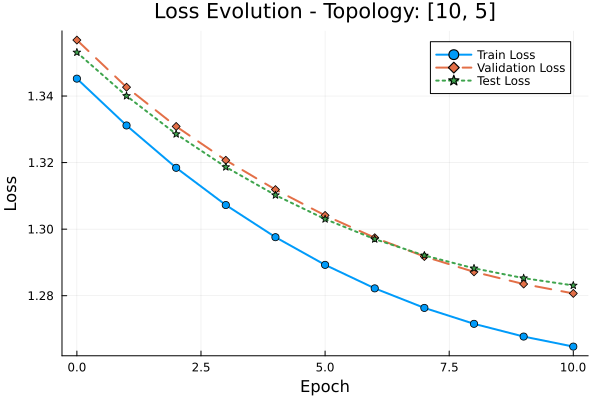

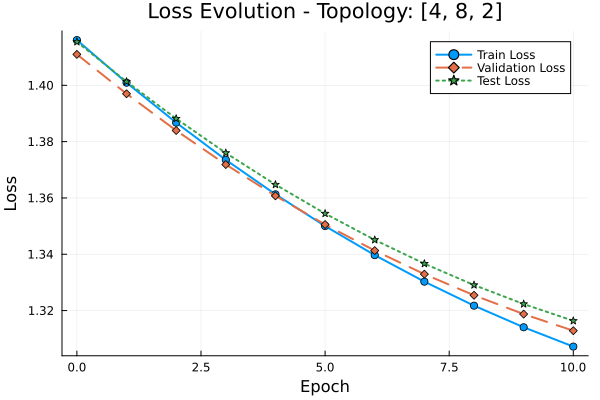

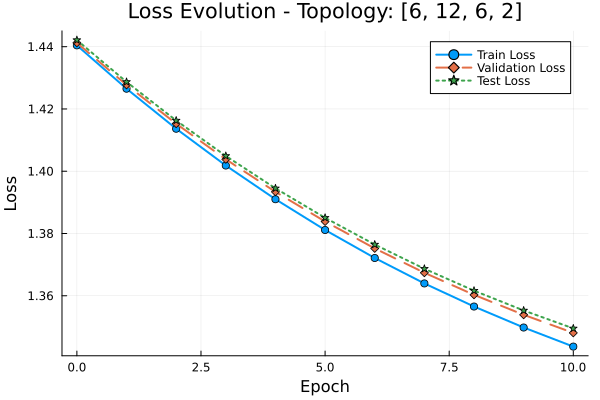

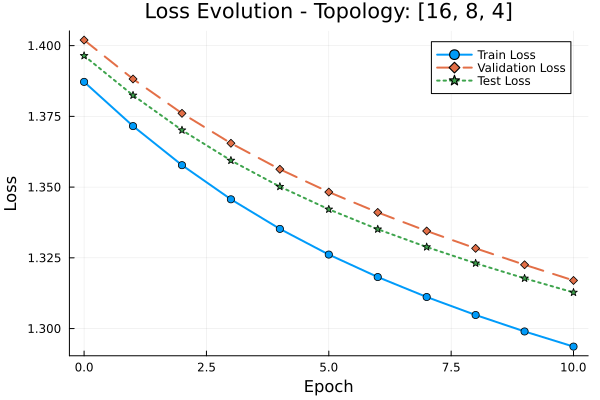

In [9]:
using Flux
using Statistics
using Plots

# --- Define accuracy so trainClassANN can call it ---
accuracy(pred::Vector{Int}, truth::Vector{Int}) = mean(pred .== truth)
const Accuracy = accuracy  # optional if needed elsewhere

# Alias for Flux losses
const Losses = Flux

architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2],
    [16, 8, 4]
]

# --- Store all results ---
results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}}}()

# Extract unique classes for one-hot encoding
classes = unique(trainingTargets)

for topology in architectures
    println("\nTraining architecture: ", topology)

    # One-hot encode the targets
    trainingTargetsOH = oneHotEncoding(trainingTargets, classes)
    valTargetsOH      = oneHotEncoding(valTargets, classes)
    testTargetsOH     = oneHotEncoding(testTargets, classes)

    # Train the network
    finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
        topology,
        (trainingInputs, trainingTargetsOH),
        validationDataset = (valInputs, valTargetsOH),
        testDataset = (testInputs, testTargetsOH),
        maxEpochs = 10,
        learningRate = 0.01,
        showText = true
    )

    results[string(topology)] = (trainLoss, valLoss, testLoss)

    # --- Compute confusion matrix on test set ---
    testOutputs = finalAnn(testInputs')
    testPredictions = classifyOutputs(testOutputs')  # boolean matrix
    cm_metrics = confusionMatrix(testPredictions, testTargetsOH)

    println("\nConfusion matrix for architecture ", topology, ":")
    println(cm_metrics[end])  # last element is the actual confusion matrix
end

# --- Plotting all losses, one plot per model ---
for (topology, (trainLoss, valLoss, testLoss)) in results
    epochs = 0:length(trainLoss)-1  # include epoch 0

    p = plot(epochs, trainLoss, label="Train Loss", lw=2, marker=:circle)
    
    if !isempty(valLoss)
        plot!(p, epochs, valLoss, label="Validation Loss", lw=2, linestyle=:dash, marker=:diamond)
    end
    
    if !isempty(testLoss)
        plot!(p, epochs, testLoss, label="Test Loss", lw=2, linestyle=:dot, marker=:star)
    end

    xlabel!("Epoch")
    ylabel!("Loss")
    title!("Loss Evolution - Topology: $(topology)")
    plot!(legend=:topright)
    
    display(p)  # show the plot
end
